# RQ2 — Facilities & Measures to Accommodate Population Growth

**Research Question 2:** *What facilities need to grow faster, or what other
considerable measures should the municipality of Eindhoven take to accommodate
the growth in population?*

This notebook answers RQ2 by running the **five SPARQL queries** defined in
[`queries.md`](../queries.md) **directly against the knowledge graph**
(`data/processed/data.ttl`) with `rdflib`, loading each result into pandas, and
visualising it. Every section follows the same shape:

> **goal → SPARQL → analysis → visualisation → interpretation**

and the notebook closes with a synthesis of concrete recommendations for the
municipality.

**A note on coverage.** Several RQ2 queries use *mandatory* (non-`OPTIONAL`)
triple patterns, so a neighbourhood is only returned when **all** requested
values exist for the requested years. In the graph, `population` is present on
1,328/1,392 observations and facility distances on ~1,218/1,392, so strict-join
queries return fewer than the full 116 neighbourhoods. This is faithful SPARQL
behaviour — we report it rather than imputing missing cells (consistent with the
project's *flag-don't-impute* convention).

In [1]:
!pip install rdflib seaborn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from rdflib import Graph

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

In [3]:
# Load the knowledge graph emitted by knowledge_graph.ipynb.
g = Graph()
g.parse("../data/processed/data.ttl", format="turtle")
print(f"Knowledge graph loaded: {len(g):,} triples")

Knowledge graph loaded: 69,156 triples


In [4]:
def run_query(sparql: str) -> pd.DataFrame:
    """Run a SPARQL SELECT against the graph and return a typed DataFrame.

    Binding values are converted with rdflib's ``.toPython()``; unbound OPTIONAL
    cells become ``NaN``. Columns that are fully numeric are then coerced so we
    can do arithmetic and plotting. This single helper backs all five queries.
    """
    res = g.query(sparql)
    cols = [str(v) for v in res.vars]
    rows = [
        [(b.get(v).toPython() if b.get(v) is not None else None) for v in res.vars]
        for b in res.bindings
    ]
    df = pd.DataFrame(rows, columns=cols)
    for c in df.columns:
        coerced = pd.to_numeric(df[c], errors="coerce")
        # adopt the numeric version only if no real value was lost (i.e. truly numeric)
        if coerced.notna().sum() >= df[c].notna().sum():
            df[c] = coerced
    return df

## Query 1 — Facility access in high-growth neighbourhoods

**Goal.** Identify neighbourhoods that grew in population between 2015 and 2025
and show their **2025 distances to seven essential facilities**, ordered by
growth — surfacing the places under the most demographic pressure.

In [5]:
q1 = """
PREFIX ein: <http://eindhoven.nl/livability/>
SELECT ?name (?p2 - ?p1 AS ?growth)
       ?supermarket ?groceries ?gp ?pharmacy ?primarySchool ?daycare ?trainStation
WHERE {
  ?nb ein:hasName ?name ; ein:hasObservation ?o1 , ?o2 .
  ?o1 ein:inYear 2015 ; ein:population ?p1 .
  ?o2 ein:inYear 2025 ; ein:population ?p2 ;
      ein:distSupermarket    ?supermarket ;
      ein:distDailyGroceries ?groceries ;
      ein:distGpPractice     ?gp ;
      ein:distPharmacy       ?pharmacy ;
      ein:distPrimarySchool  ?primarySchool ;
      ein:distDaycare        ?daycare ;
      ein:distTrainStation   ?trainStation .
  FILTER (?p2 > ?p1)
}
ORDER BY DESC(?growth)
"""
q1_df = run_query(q1)
print(f"{len(q1_df)} neighbourhoods grew in population between 2015 and 2025")
q1_df.head(15)

81 neighbourhoods grew in population between 2015 and 2025


,name,growth,supermarket,groceries,gp,pharmacy,primarySchool,daycare,trainStation
0,Strijp S,2419.0,0.5,0.4,1.1,1.1,1.1,1.1,1.0
1,TU-terrein,2019.0,0.5,1.3,1.3,1.4,1.5,0.4,2.1
2,Woensel-West,1763.0,0.5,0.4,0.6,0.6,0.6,0.6,0.7
3,Waterrijk,1530.0,1.9,1.9,1.9,1.8,1.6,0.6,6.2
4,Tongelresche Akkers,1358.0,0.6,1.5,0.9,0.9,0.3,0.6,3.6
5,Witte Dame,1162.0,0.2,0.2,1.0,1.0,1.0,1.0,1.2
6,Zwaanstraat,1119.0,1.2,1.1,1.5,1.5,0.9,0.7,1.9
7,Binnenstad,998.0,0.5,0.2,0.9,1.0,0.8,0.8,1.0
8,Irisbuurt,878.0,0.5,0.5,1.0,1.0,0.8,0.6,1.9
9,Meerrijk,878.0,0.1,0.1,0.1,0.1,0.2,0.1,5.3


In [6]:
# Analysis: how do the highest-growth neighbourhoods compare to the city-wide
# average distance for each essential facility?
facility_cols = ["supermarket", "groceries", "gp", "pharmacy",
                 "primarySchool", "daycare", "trainStation"]

city_mean = q1_df[facility_cols].mean()
print("City-wide mean 2025 distance to each essential facility (km):")
print(city_mean.round(2).to_string())

top15 = q1_df.head(15).copy()
top15["avg_essential_km"] = top15[facility_cols].mean(axis=1)
above = (top15[facility_cols] > city_mean).sum(axis=1)
summary = top15[["name", "growth", "avg_essential_km"]].assign(
    facilities_worse_than_city=above.values)
print("\nTop-15 growth neighbourhoods vs the city facility means:")
summary.round(2)

City-wide mean 2025 distance to each essential facility (km):
supermarket      0.84
groceries        0.72
gp               0.92
pharmacy         1.02
primarySchool    0.77
daycare          0.69
trainStation     3.29

Top-15 growth neighbourhoods vs the city facility means:


,name,growth,avg_essential_km,facilities_worse_than_city
0,Strijp S,2419.0,0.90,4
1,TU-terrein,2019.0,1.21,4
2,Woensel-West,1763.0,0.57,0
3,Waterrijk,1530.0,2.27,6
4,Tongelresche Akkers,1358.0,1.20,2
5,Witte Dame,1162.0,0.80,3
6,Zwaanstraat,1119.0,1.26,6
7,Binnenstad,998.0,0.74,2
8,Irisbuurt,878.0,0.90,2
9,Meerrijk,878.0,0.86,1


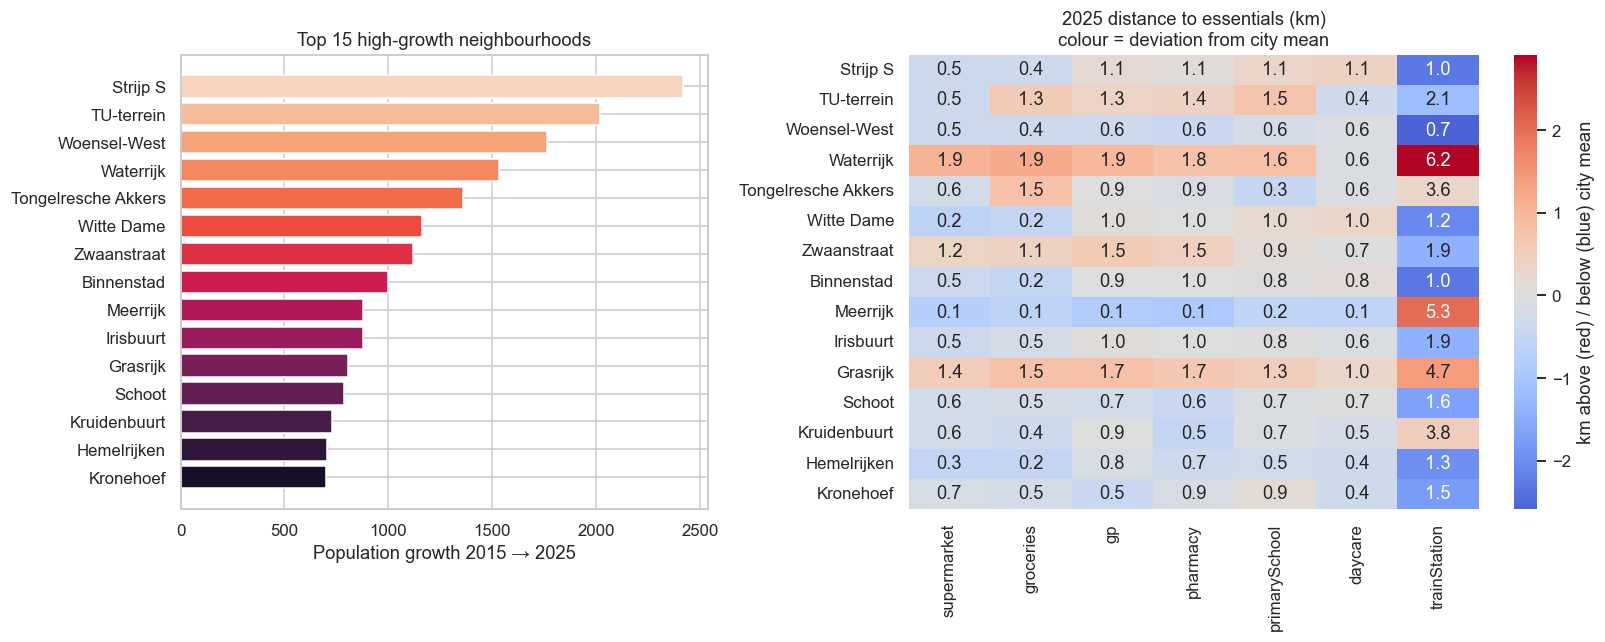

In [7]:
# Visualisation: (a) population growth of the top 15, (b) their 2025 facility
# distances coloured by deviation from the city mean (hot = worse access).
fig, axes = plt.subplots(1, 2, figsize=(15, 6),
                         gridspec_kw={"width_ratios": [1, 1.35]})

order = top15.sort_values("growth")
axes[0].barh(order["name"], order["growth"],
             color=sns.color_palette("rocket", len(order)))
axes[0].set_xlabel("Population growth 2015 → 2025")
axes[0].set_title("Top 15 high-growth neighbourhoods")

row_order = order["name"][::-1]                       # largest growth at the top
abs_km = top15.set_index("name")[facility_cols].loc[row_order]
dev = abs_km.subtract(city_mean, axis=1)
sns.heatmap(dev, cmap="coolwarm", center=0, annot=abs_km, fmt=".1f",
            cbar_kws={"label": "km above (red) / below (blue) city mean"},
            ax=axes[1])
axes[1].set_title("2025 distance to essentials (km)\ncolour = deviation from city mean")
axes[1].set_xlabel(""); axes[1].set_ylabel("")
plt.tight_layout(); plt.show()

**Interpretation.** The left bar ranks demographic pressure; the heatmap
shows whether that pressure meets adequate infrastructure. Red cells mark
facilities that are *further away than the city average* for a fast-growing
neighbourhood — exactly the growth/access mismatch RQ2 is looking for. Train
station and (secondary) school distances tend to dominate the red, while
supermarket/GP/pharmacy are typically close everywhere. Neighbourhoods with both
a long bar **and** red cells are the first cross-reference candidates for
Query 3.

## Query 2 — Population growth vs housing growth

**Goal.** Compare population growth against dwelling growth (2015–2025)
alongside the 2025 occupancy rate — directly testing whether housing supply is
keeping pace with demand.

In [8]:
q2 = """
PREFIX ein: <http://eindhoven.nl/livability/>
SELECT ?name (?p2 - ?p1 AS ?popGrowth) (?dw2 - ?dw1 AS ?dwellingGrowth) ?pctOccupied2025
WHERE {
  ?nb ein:hasName ?name ; ein:hasObservation ?o1 , ?o2 .
  ?o1 ein:inYear 2015 ; ein:population ?p1 ; ein:totalDwellings ?dw1 .
  ?o2 ein:inYear 2025 ; ein:population ?p2 ; ein:totalDwellings ?dw2 ;
      ein:pctOccupied ?pctOccupied2025 .
  FILTER (?p2 > ?p1)
}
ORDER BY DESC(?popGrowth)
"""
q2_df = run_query(q2)
print(f"{len(q2_df)} growing neighbourhoods with housing + occupancy data")
q2_df.head(10)

77 growing neighbourhoods with housing + occupancy data


,name,popGrowth,dwellingGrowth,pctOccupied2025
0,Strijp S,2419.0,1731.0,0.95
1,TU-terrein,2019.0,926.0,0.98
2,Woensel-West,1763.0,714.0,0.97
3,Waterrijk,1530.0,529.0,0.96
4,Tongelresche Akkers,1358.0,501.0,0.97
5,Witte Dame,1162.0,900.0,0.87
6,Zwaanstraat,1119.0,388.0,0.96
7,Binnenstad,998.0,551.0,0.86
8,Irisbuurt,878.0,437.0,0.93
9,Meerrijk,878.0,368.0,0.94


In [9]:
# Analysis: ratio of dwelling growth to population growth (<1 => population is
# outpacing housing) and which neighbourhoods are near full occupancy.
q2_df["dwelling_per_pop_ratio"] = q2_df["dwellingGrowth"] / q2_df["popGrowth"]
undersupplied = q2_df[q2_df["dwelling_per_pop_ratio"] < 1.0]
full_capacity = q2_df[q2_df["pctOccupied2025"] >= 0.98]

print(f"{len(undersupplied)}/{len(q2_df)} growing neighbourhoods added fewer "
      f"dwellings than residents (ratio < 1).")
print(f"{len(full_capacity)} growing neighbourhoods sit at/near full occupancy "
      f"(>= 98%).")

stressed = q2_df[(q2_df["dwelling_per_pop_ratio"] < 1.0) &
                 (q2_df["pctOccupied2025"] >= 0.97)]
print("\nMost housing-stressed (housing lagging AND >= 97% occupied):")
stressed.sort_values("popGrowth", ascending=False).head(10).round(3)

64/77 growing neighbourhoods added fewer dwellings than residents (ratio < 1).
11 growing neighbourhoods sit at/near full occupancy (>= 98%).

Most housing-stressed (housing lagging AND >= 97% occupied):


,name,popGrowth,dwellingGrowth,pctOccupied2025,dwelling_per_pop_ratio
1,TU-terrein,2019.0,926.0,0.98,0.459
2,Woensel-West,1763.0,714.0,0.97,0.405
4,Tongelresche Akkers,1358.0,501.0,0.97,0.369
10,Grasrijk,804.0,264.0,0.98,0.328
12,Kruidenbuurt,730.0,278.0,0.97,0.381
15,Blixembosch-Oost,693.0,394.0,0.98,0.569
21,Villapark,428.0,363.0,0.97,0.848
24,Drents Dorp,320.0,192.0,0.97,0.600
30,Genderdal,205.0,86.0,0.97,0.420
35,Sintenbuurt,158.0,116.0,0.97,0.734


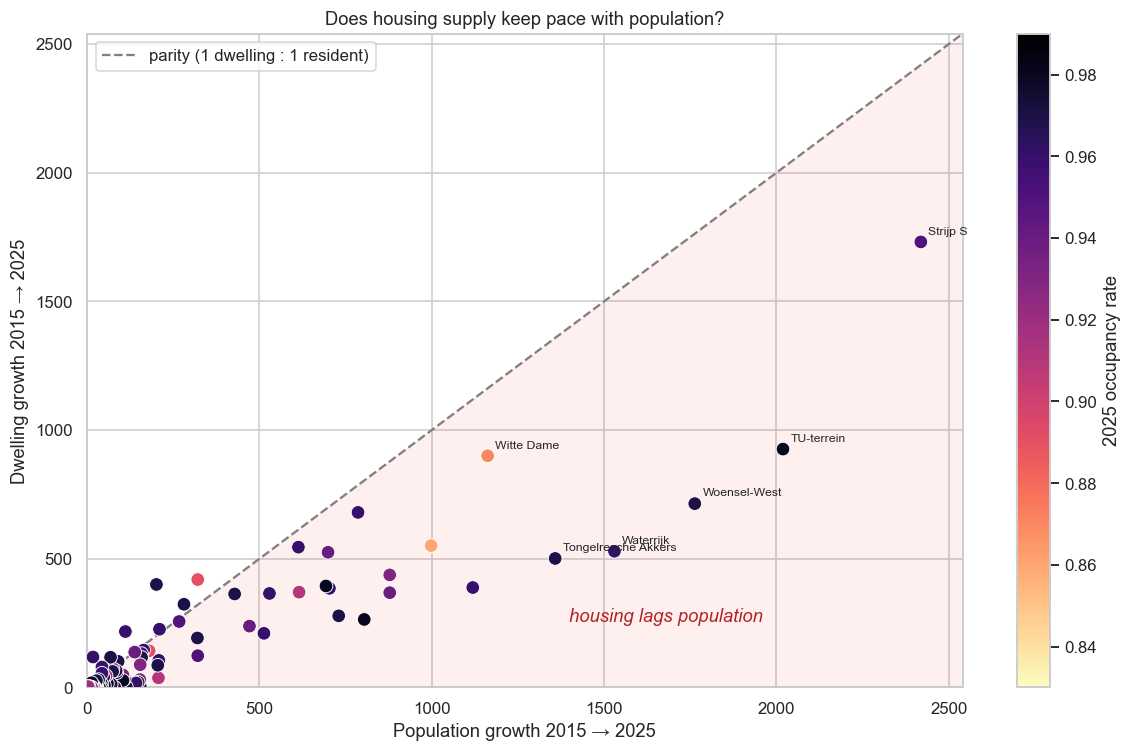

In [10]:
# Visualisation: population vs dwelling growth. Points below the parity line
# added fewer dwellings than residents; colour encodes 2025 occupancy.
fig, ax = plt.subplots(figsize=(11, 7))
sc = ax.scatter(q2_df["popGrowth"], q2_df["dwellingGrowth"],
                c=q2_df["pctOccupied2025"], cmap="magma_r", s=80,
                edgecolor="white", linewidth=0.6, zorder=3)

lim = max(q2_df["popGrowth"].max(), q2_df["dwellingGrowth"].max()) * 1.05
ax.plot([0, lim], [0, lim], ls="--", color="grey",
        label="parity (1 dwelling : 1 resident)")
ax.fill_between([0, lim], [0, 0], [0, lim], color="red", alpha=0.06)
ax.text(lim * 0.55, lim * 0.10, "housing lags population", color="firebrick",
        fontsize=12, style="italic")

for _, r in q2_df.nlargest(6, "popGrowth").iterrows():
    ax.annotate(r["name"], (r["popGrowth"], r["dwellingGrowth"]),
                fontsize=8, xytext=(5, 5), textcoords="offset points")

ax.set_xlabel("Population growth 2015 → 2025")
ax.set_ylabel("Dwelling growth 2015 → 2025")
ax.set_title("Does housing supply keep pace with population?")
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
cbar = fig.colorbar(sc, ax=ax); cbar.set_label("2025 occupancy rate")
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

**Interpretation.** Points on or above the dashed line added at least one
dwelling per extra resident; points in the shaded region did not. Neighbourhoods
that are simultaneously **below the line** and **dark** (near-full occupancy)
have the least slack: population is rising, housing is not keeping up, and there
is no spare capacity to absorb the difference. These are prime candidates for
*housing* measures (the "other considerable measures" half of RQ2), distinct
from the *facility* gaps surfaced by the other queries.

## Query 3 — High-growth neighbourhoods ranked by essential distance

**Goal.** Among neighbourhoods that grew by **> 500 residents**, rank by a
composite average distance across seven essential facility types — pinpointing
where infrastructure is most clearly failing to keep pace with growth.

In [11]:
q3 = """
PREFIX ein: <http://eindhoven.nl/livability/>
SELECT ?name (?p2 - ?p1 AS ?growth)
       ((?super + ?groc + ?gp + ?pharm + ?prim + ?day + ?train) / 7 AS ?avgEssentialKm)
       ?train
WHERE {
  ?nb ein:hasName ?name ; ein:hasObservation ?o1 , ?o2 .
  ?o1 ein:inYear 2015 ; ein:population ?p1 .
  ?o2 ein:inYear 2025 ; ein:population ?p2 ;
      ein:distSupermarket    ?super ;
      ein:distDailyGroceries ?groc ;
      ein:distGpPractice     ?gp ;
      ein:distPharmacy       ?pharm ;
      ein:distPrimarySchool  ?prim ;
      ein:distDaycare        ?day ;
      ein:distTrainStation   ?train .
  FILTER (?p2 - ?p1 > 500)
}
ORDER BY DESC(?avgEssentialKm)
"""
q3_df = run_query(q3)
print(f"{len(q3_df)} neighbourhoods grew by more than 500 residents (2015→2025)")
q3_df.round(2)

20 neighbourhoods grew by more than 500 residents (2015→2025)


,name,growth,avgEssentialKm,train
0,Waterrijk,1530.0,2.27,6.2
1,Castiliëlaan,615.0,2.13,6.0
2,Grasrijk,804.0,1.90,4.7
3,Blixembosch-Oost,693.0,1.33,5.7
4,Zwaanstraat,1119.0,1.26,1.9
5,TU-terrein,2019.0,1.21,2.1
6,Tongelresche Akkers,1358.0,1.20,3.6
7,Woenselse Watermolen,513.0,1.11,1.6
8,Kruidenbuurt,730.0,1.06,3.8
9,Rapelenburg,529.0,0.94,3.1


In [12]:
# Analysis: reuse the Query 1 result (it carries all seven distances) to find
# WHICH facility drives each neighbourhood's high average -- no second query.
q1_idx = q1_df.set_index("name")
drivers = [(name,
            q1_idx.loc[name, facility_cols].idxmax(),
            round(q1_idx.loc[name, facility_cols].max(), 2))
           for name in q3_df["name"] if name in q1_idx.index]
driver_df = pd.DataFrame(drivers, columns=["name", "worst_facility", "worst_km"])

q3_annot = q3_df.merge(driver_df, on="name", how="left")
print("High-growth (>500) neighbourhoods by avg essential distance, with the "
      "facility driving the average:")
q3_annot[["name", "growth", "avgEssentialKm", "worst_facility", "worst_km"]].round(2)

High-growth (>500) neighbourhoods by avg essential distance, with the facility driving the average:


,name,growth,avgEssentialKm,worst_facility,worst_km
0,Waterrijk,1530.0,2.27,trainStation,6.2
1,Castiliëlaan,615.0,2.13,trainStation,6.0
2,Grasrijk,804.0,1.90,trainStation,4.7
3,Blixembosch-Oost,693.0,1.33,trainStation,5.7
4,Zwaanstraat,1119.0,1.26,trainStation,1.9
5,TU-terrein,2019.0,1.21,trainStation,2.1
6,Tongelresche Akkers,1358.0,1.20,trainStation,3.6
7,Woenselse Watermolen,513.0,1.11,gp,1.6
8,Kruidenbuurt,730.0,1.06,trainStation,3.8
9,Rapelenburg,529.0,0.94,trainStation,3.1


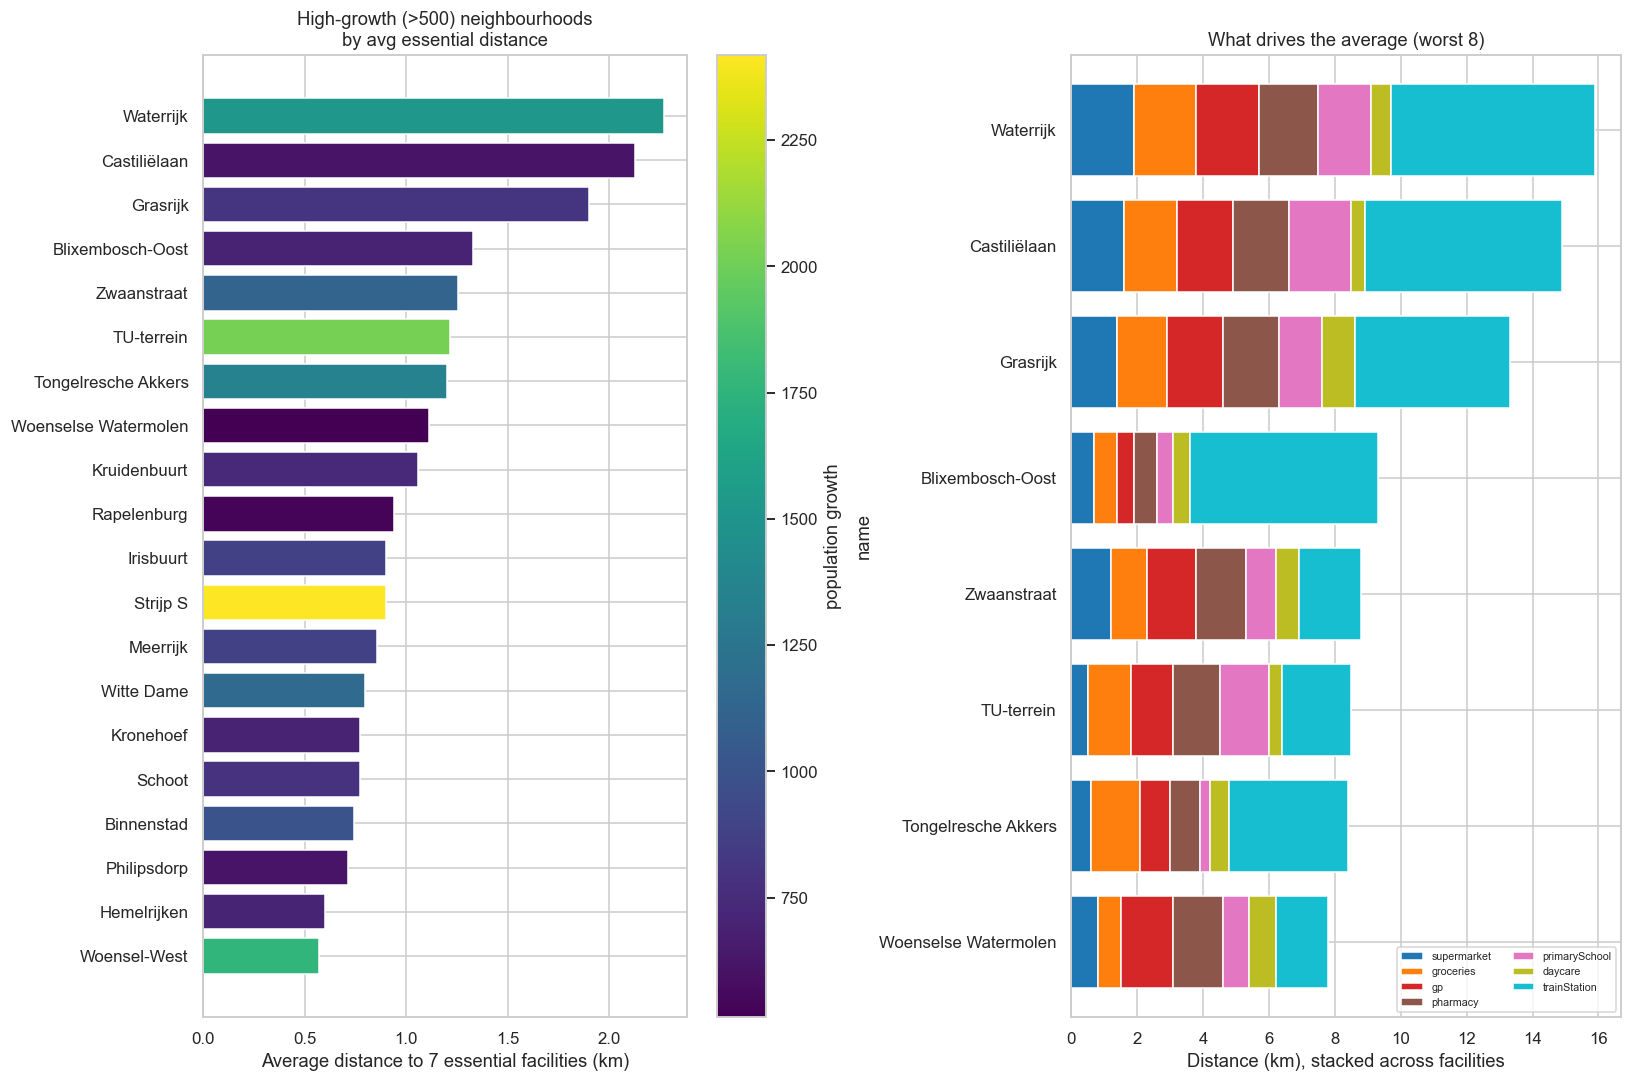

In [13]:
# Visualisation: (a) ranked average distance coloured by growth, (b) stacked
# facility components for the worst few to expose the driver.
fig, axes = plt.subplots(1, 2, figsize=(15, max(4.5, 0.5 * len(q3_df))),
                         gridspec_kw={"width_ratios": [1.1, 1]})

order = q3_df.sort_values("avgEssentialKm")
norm = plt.Normalize(order["growth"].min(), order["growth"].max())
axes[0].barh(order["name"], order["avgEssentialKm"],
             color=plt.cm.viridis(norm(order["growth"])))
axes[0].set_xlabel("Average distance to 7 essential facilities (km)")
axes[0].set_title("High-growth (>500) neighbourhoods\nby avg essential distance")
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm); sm.set_array([])
fig.colorbar(sm, ax=axes[0], label="population growth")

worst = q3_df.head(8).set_index("name")
comp = q1_df.set_index("name").loc[worst.index, facility_cols]
comp.plot(kind="barh", stacked=True, ax=axes[1], colormap="tab10", width=0.8)
axes[1].invert_yaxis()
axes[1].set_xlabel("Distance (km), stacked across facilities")
axes[1].set_title("What drives the average (worst 8)")
axes[1].legend(fontsize=7, ncol=2, loc="lower right")
plt.tight_layout(); plt.show()

**Interpretation.** The neighbourhoods at the **top of the left chart**
(high average distance) that are also **bright/yellow** (large population growth)
are the strongest case for infrastructure investment: many new residents, far
from essentials. The stacked breakdown shows the *specific* facility to target —
typically the train station and secondary school stretch the average, whereas
groceries and primary care are short almost everywhere. That distinction matters
for a municipal recommendation: it is cheaper and more effective to add the one
or two facility types that dominate the distance than to treat "access" as a
single number.

## Query 4 — Average facility distances over time vs population

**Goal.** Track whether average distances to essential facilities across *all*
Eindhoven neighbourhoods rose, fell, or stayed flat over 2015–2025, set
against total population growth. This is the headline RQ2 figure.

In [14]:
q4 = """
PREFIX ein: <http://eindhoven.nl/livability/>
SELECT ?year
       (AVG(?distGp) as ?avgDistGp)
       (AVG(?distHospital) as ?avgDistHospital)
       (AVG(?distPrimary) as ?avgDistPrimary)
       (AVG(?distSecondary) as ?avgDistSecondary)
       (AVG(?distTrain) as ?avgDistTrain)
       (AVG(?distSupermarket) as ?avgDistSupermarket)
       (AVG(?distPharmacy) as ?avgDistPharmacy)
       (AVG(?distDaycare) as ?avgDistDaycare)
       (SUM(?population) as ?totalPopulation)
WHERE {
    ?obs a ein:Observation ;
         ein:inYear ?year ;
         ein:population ?population .
    OPTIONAL { ?obs ein:distGpPractice ?distGp . }
    OPTIONAL { ?obs ein:distHospital ?distHospital . }
    OPTIONAL { ?obs ein:distPrimarySchool ?distPrimary . }
    OPTIONAL { ?obs ein:distSecondarySchool ?distSecondary . }
    OPTIONAL { ?obs ein:distTrainStation ?distTrain . }
    OPTIONAL { ?obs ein:distSupermarket ?distSupermarket . }
    OPTIONAL { ?obs ein:distPharmacy ?distPharmacy . }
    OPTIONAL { ?obs ein:distDaycare ?distDaycare . }
}
GROUP BY ?year
ORDER BY ?year
"""
q4_df = run_query(q4).sort_values("year").reset_index(drop=True)

# AVG over an empty group returns 0 in SPARQL, not NULL. 2014 has no facility
# data at all, and secondary-school distance is absent in 2025 -> those surface
# as 0.0 km, which is impossible. Treat exact 0 in the distance averages as
# missing so trends and % changes use only real measurements.
avg_cols = [c for c in q4_df.columns if c.startswith("avgDist")]
q4_df[avg_cols] = q4_df[avg_cols].replace(0, np.nan)
q4_df.round(2)

,year,avgDistGp,avgDistHospital,avgDistPrimary,avgDistSecondary,avgDistTrain,avgDistSupermarket,avgDistPharmacy,avgDistDaycare,totalPopulation
0,2014,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,220917.0
1,2015,0.98,2.78,0.81,1.48,3.22,0.93,1.05,0.68,223208.0
2,2016,0.98,3.42,0.81,1.48,3.23,0.92,1.05,0.68,224776.0
3,2017,0.97,3.38,0.77,1.44,3.28,0.91,1.05,0.65,226916.0
4,2018,0.98,3.38,0.79,1.43,3.30,0.91,1.06,0.65,229131.0
5,2019,0.90,3.39,0.75,1.43,3.15,0.84,1.02,0.63,231601.0
6,2020,0.97,3.41,0.77,1.45,3.26,0.82,1.07,0.65,234382.0
7,2021,0.98,3.41,0.75,1.41,3.27,0.84,1.07,0.63,235662.0
8,2022,1.04,3.48,0.83,1.48,3.41,0.91,1.14,0.71,238281.0
9,2023,1.05,3.48,0.83,1.49,3.41,0.91,1.15,0.73,243714.0


In [15]:
# Analysis: percentage change in each facility distance against population.
dist_cols = ["avgDistGp", "avgDistHospital", "avgDistPrimary", "avgDistSecondary",
             "avgDistTrain", "avgDistSupermarket", "avgDistPharmacy", "avgDistDaycare"]

p_first, p_last = q4_df.iloc[0], q4_df.iloc[-1]
pop_change = (p_last["totalPopulation"] / p_first["totalPopulation"] - 1) * 100
print(f"Total population {int(p_first['year'])}→{int(p_last['year'])}: "
      f"{p_first['totalPopulation']:,.0f} → {p_last['totalPopulation']:,.0f} "
      f"({pop_change:+.1f}%)\n")

# Each facility has its own measured span (secondary school is not recorded in
# 2025), so compare each column's first vs last *valid* year.
rows = []
for col in dist_cols:
    s = q4_df.set_index("year")[col].dropna()
    rows.append((col.replace("avgDist", ""), int(s.index[0]), int(s.index[-1]),
                 round((s.iloc[-1] / s.iloc[0] - 1) * 100, 1)))
chg = (pd.DataFrame(rows, columns=["facility", "from", "to", "pct_change"])
         .sort_values("pct_change"))
print("Change in avg facility distance over each facility's available span "
      "(negative = residents got closer):")
print(chg.to_string(index=False))

Total population 2014→2025: 220,917 → 249,018 (+12.7%)

Change in avg facility distance over each facility's available span (negative = residents got closer):
   facility  from   to  pct_change
Supermarket  2015 2025        -3.0
  Secondary  2015 2024         0.9
    Primary  2015 2025         2.3
         Gp  2015 2025         3.5
      Train  2015 2025         5.3
   Pharmacy  2015 2025         5.7
    Daycare  2015 2025         7.0
   Hospital  2015 2025        25.6


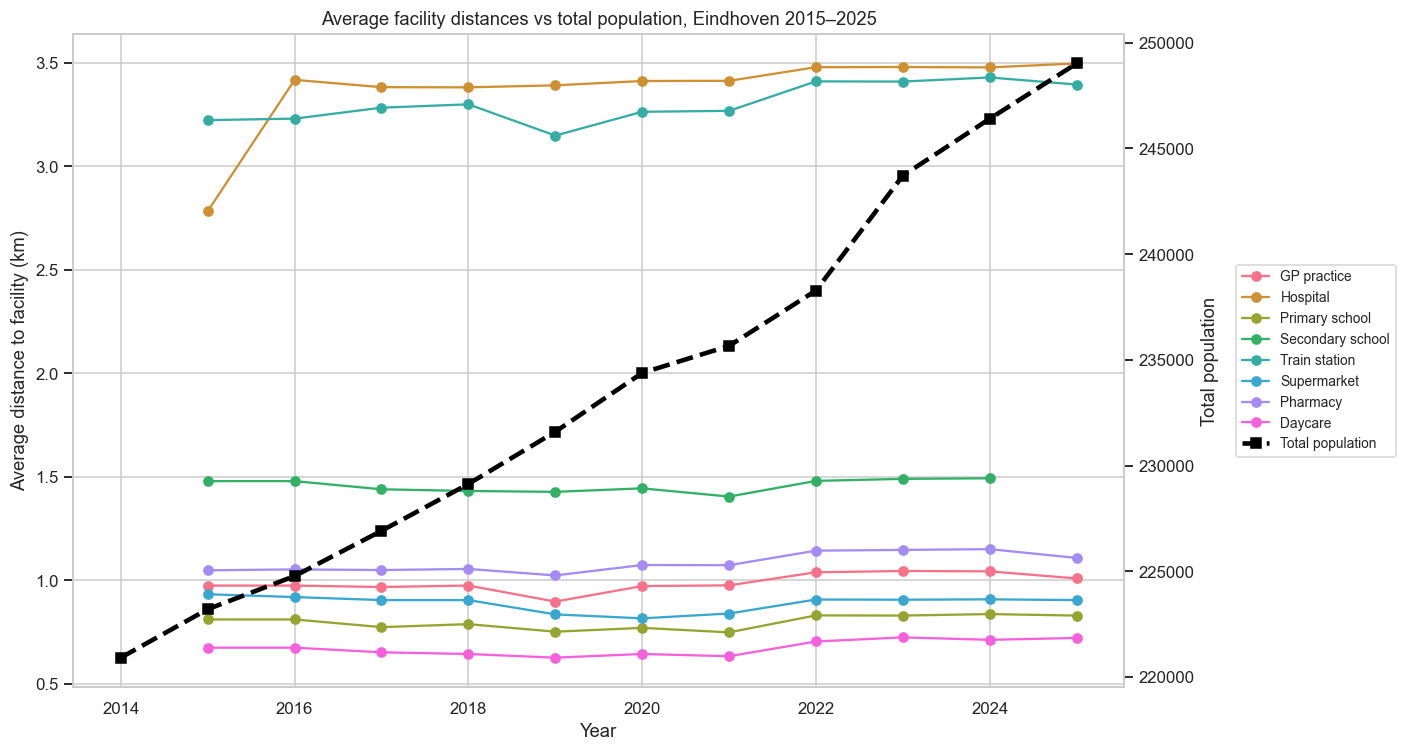

In [16]:
# Visualisation: facility distances (left axis) vs total population (right axis).
# NaN cells (2014 for all facilities, 2025 for secondary school) leave a gap, so
# each line spans only the years it was actually measured.
fig, ax = plt.subplots(figsize=(13, 7))
labels = {"avgDistGp": "GP practice", "avgDistHospital": "Hospital",
          "avgDistPrimary": "Primary school", "avgDistSecondary": "Secondary school",
          "avgDistTrain": "Train station", "avgDistSupermarket": "Supermarket",
          "avgDistPharmacy": "Pharmacy", "avgDistDaycare": "Daycare"}
palette = sns.color_palette("husl", len(dist_cols))

for col, c in zip(dist_cols, palette):
    ax.plot(q4_df["year"], q4_df[col], marker="o", color=c, label=labels[col])
ax.set_xlabel("Year"); ax.set_ylabel("Average distance to facility (km)")
ax.set_title("Average facility distances vs total population, Eindhoven 2015–2025")

ax2 = ax.twinx()
ax2.plot(q4_df["year"], q4_df["totalPopulation"], color="black", lw=3, ls="--",
         marker="s", label="Total population")
ax2.set_ylabel("Total population"); ax2.grid(False)

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="center left", bbox_to_anchor=(1.10, 0.5), fontsize=9)
plt.tight_layout(); plt.show()

**Interpretation.** The dashed black line shows population climbing
steadily. If the coloured facility lines were *flat or falling* while population
rose, the city would be adding facilities in step with growth. Where a line
**slopes upward** as population rises, residents are on average getting *further*
from that facility — a direct, city-wide signal for RQ2. Read the printed
percentage table alongside the chart: facilities with the largest positive
change are the ones the municipality is failing to scale proportionally.

## Query 5 — Worst facility access in 2024

**Goal.** List the ten neighbourhoods with the worst access to key facilities in
2024 (ranked by distance to a GP practice) — a concrete "at-risk" shortlist,
read together with how many residents each one holds.

In [17]:
q5 = """
PREFIX ein: <http://eindhoven.nl/livability/>
SELECT ?neighborhood ?distGp ?distHospital
       ?distPrimary ?distSecondary ?distTrain
       ?population
WHERE {
    ?obs a ein:Observation ;
         ein:inNeighborhood ?nb ;
         ein:inYear ?year ;
         ein:population ?population .
    ?nb ein:hasName ?neighborhood .
    OPTIONAL { ?obs ein:distGpPractice ?distGp . }
    OPTIONAL { ?obs ein:distHospital ?distHospital . }
    OPTIONAL { ?obs ein:distPrimarySchool ?distPrimary . }
    OPTIONAL { ?obs ein:distSecondarySchool ?distSecondary . }
    OPTIONAL { ?obs ein:distTrainStation ?distTrain . }
    FILTER (?year = 2024)
}
ORDER BY DESC(?distGp)
LIMIT 10
"""
q5_df = run_query(q5)
q5_df.round(2)

,neighborhood,distGp,distHospital,distPrimary,distSecondary,distTrain,population
0,BeA2,4.0,6.8,3.2,3.4,5.5,28.0
1,Mispelhoef,4.0,6.4,2.9,2.9,5.1,19.0
2,Herdgang,3.0,4.4,1.1,1.2,3.0,13.0
3,Wielewaal,2.9,4.9,1.1,1.1,3.5,115.0
4,Bosrijk,2.6,5.8,0.9,4.6,5.7,606.0
5,Park Forum,2.6,6.2,2.3,6.1,7.2,25.0
6,Grasrijk,2.2,4.7,1.2,3.6,4.7,5950.0
7,Meerbos,2.1,5.6,1.6,2.5,3.8,60.0
8,Bokt,1.9,4.9,1.6,1.9,6.5,127.0
9,Esp,1.9,4.8,1.8,1.8,6.4,18.0


In [18]:
# Analysis: distance profile + the population exposed to that poor access.
q5_dist_cols = ["distGp", "distHospital", "distPrimary", "distSecondary", "distTrain"]
q5_df["avg_dist_km"] = q5_df[q5_dist_cols].mean(axis=1)
print("Worst GP access in 2024 — and the population exposed to it:")
print(q5_df[["neighborhood", "distGp", "population", "avg_dist_km"]]
      .round(2).to_string(index=False))
print(f"\nCombined population of these 10 worst-access neighbourhoods: "
      f"{q5_df['population'].sum():,.0f}")

Worst GP access in 2024 — and the population exposed to it:
neighborhood  distGp  population  avg_dist_km
        BeA2     4.0        28.0         4.58
  Mispelhoef     4.0        19.0         4.26
    Herdgang     3.0        13.0         2.54
   Wielewaal     2.9       115.0         2.70
     Bosrijk     2.6       606.0         3.92
  Park Forum     2.6        25.0         4.88
    Grasrijk     2.2      5950.0         3.28
     Meerbos     2.1        60.0         3.12
        Bokt     1.9       127.0         3.36
         Esp     1.9        18.0         3.34

Combined population of these 10 worst-access neighbourhoods: 6,961


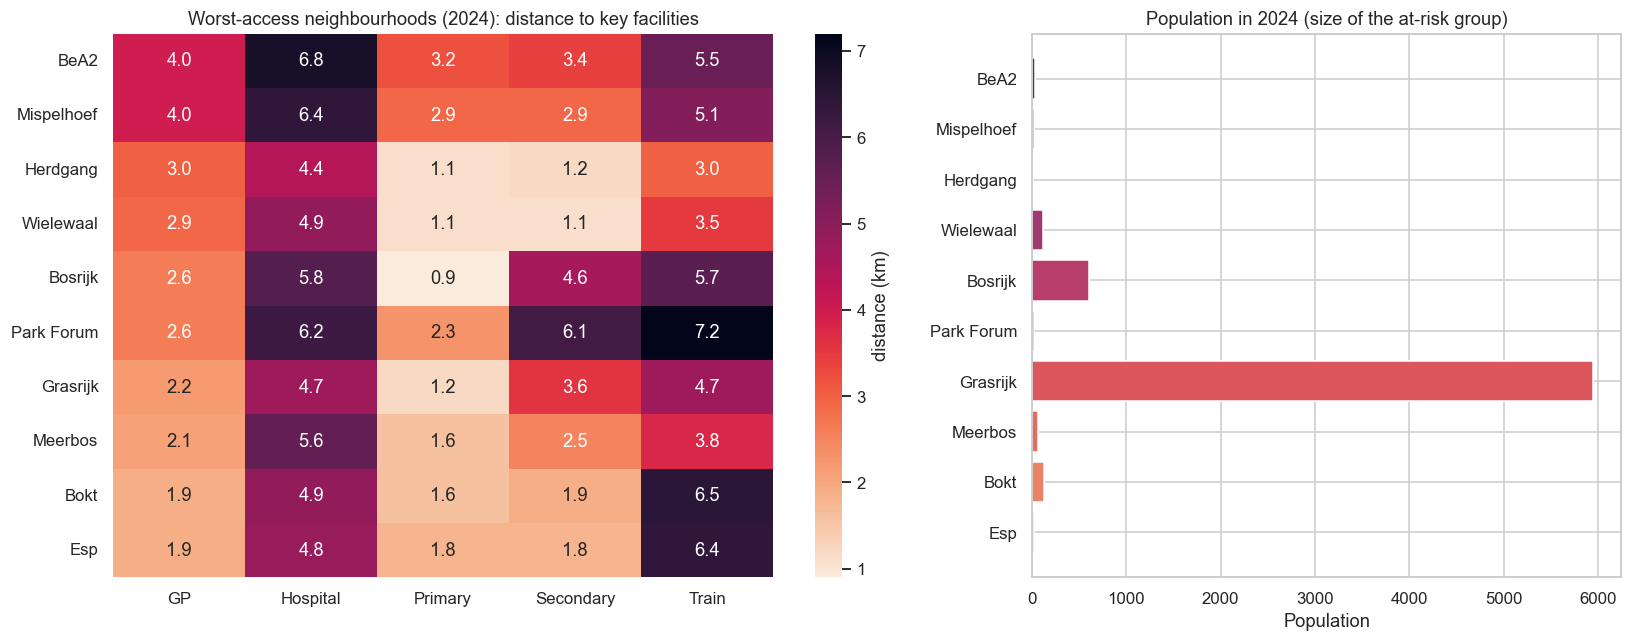

In [19]:
# Visualisation: distance heatmap (left) beside the population at stake (right).
fig, axes = plt.subplots(1, 2, figsize=(15, 6),
                         gridspec_kw={"width_ratios": [1.4, 1]})

hm = q5_df.set_index("neighborhood")[q5_dist_cols]
hm.columns = ["GP", "Hospital", "Primary", "Secondary", "Train"]
sns.heatmap(hm, annot=True, fmt=".1f", cmap="rocket_r",
            cbar_kws={"label": "distance (km)"}, ax=axes[0])
axes[0].set_title("Worst-access neighbourhoods (2024): distance to key facilities")
axes[0].set_ylabel(""); axes[0].set_xlabel("")

pop_order = q5_df.iloc[::-1]                          # align with heatmap (worst at top)
axes[1].barh(pop_order["neighborhood"], pop_order["population"],
             color=sns.color_palette("flare", len(q5_df)))
axes[1].set_title("Population in 2024 (size of the at-risk group)")
axes[1].set_xlabel("Population")
plt.tight_layout(); plt.show()

**Interpretation.** A long distance matters more where many people live.
Cross-reading the two panels separates *remote-but-tiny* neighbourhoods (poor
access, few residents — lower priority) from *remote-and-populous* ones, which
are the genuinely critical cases for a 2024 snapshot. These feed directly into
the recommendation list below.

## Synthesis — recommendations for the municipality

Pulling the five queries together to answer RQ2.

In [20]:
# Primary candidates: appear in BOTH the high-growth set (Q1) and the
# high-essential-distance ranking (Q3).
top_growth = set(q1_df.head(15)["name"])
poor_access = set(q3_df.sort_values("avgEssentialKm", ascending=False).head(10)["name"])
both = sorted(top_growth & poor_access)

print("PRIMARY INFRASTRUCTURE-INVESTMENT CANDIDATES")
print("(high population growth AND high distance to essentials):")
if both:
    for n in both:
        print(f"  - {n}")
else:
    print("  (no overlap at the strict top-N cut)")

print("\nHOUSING-STRESSED NEIGHBOURHOODS (Q2)")
print("(dwellings lagging population AND >= 97% occupied):")
for n in stressed.sort_values("popGrowth", ascending=False)["name"]:
    print(f"  - {n}")

print("\nMOST AT-RISK ON FACILITY ACCESS IN 2024 (Q5, top 3 by GP distance)")
for _, r in q5_df.head(3).iterrows():
    print(f"  - {r['neighborhood']}: GP {r['distGp']:.1f} km, pop {r['population']:,.0f}")

PRIMARY INFRASTRUCTURE-INVESTMENT CANDIDATES
(high population growth AND high distance to essentials):
  - Grasrijk
  - Kruidenbuurt
  - TU-terrein
  - Tongelresche Akkers
  - Waterrijk
  - Zwaanstraat

HOUSING-STRESSED NEIGHBOURHOODS (Q2)
(dwellings lagging population AND >= 97% occupied):
  - TU-terrein
  - Woensel-West
  - Tongelresche Akkers
  - Grasrijk
  - Kruidenbuurt
  - Blixembosch-Oost
  - Villapark
  - Drents Dorp
  - Genderdal
  - Sintenbuurt
  - Vaartbroek
  - Roosten
  - Oude Gracht-West
  - Hondsheuvels
  - Woenselse Heide
  - Hagenkamp
  - Nieuwe Erven
  - Luytelaer
  - Doornakkers-Oost
  - Tempel
  - Puttense Dreef
  - Lievendaal
  - Tivoli
  - Eckart
  - Vlokhoven
  - Jagershoef
  - Achtse Barrier-Gunterslaer

MOST AT-RISK ON FACILITY ACCESS IN 2024 (Q5, top 3 by GP distance)
  - BeA2: GP 4.0 km, pop 28
  - Mispelhoef: GP 4.0 km, pop 19
  - Herdgang: GP 3.0 km, pop 13


### Takeaways

1. **Facilities to grow faster (RQ2, part 1).** Query 4 shows which facility
   types drift *further away* city-wide as population rises; Query 3's stacked
   breakdown names the specific facility (typically train stations and secondary
   schools) that dominates the distance in the fastest-growing neighbourhoods.
   These are the categories to prioritise.
2. **Where to act first.** The primary-candidate list above — neighbourhoods
   that are simultaneously high-growth and far from essentials — is the
   shortlist for siting new facilities.
3. **Other considerable measures (RQ2, part 2).** Query 2 isolates a *housing*
   problem distinct from the facility problem: neighbourhoods adding residents
   faster than dwellings while already near full occupancy. Here the lever is
   housing supply / densification, not amenities.
4. **Protect the exposed.** Query 5 flags neighbourhoods where poor 2024 access
   coincides with a large resident population — the highest-impact targets for
   immediate mitigation (e.g. transport links, mobile services).

*All figures and tables above are generated live from the RDF knowledge graph
via the SPARQL queries in `queries.md`, so they refresh automatically if the
graph is regenerated.*